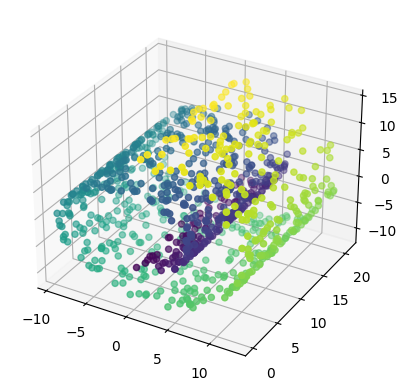

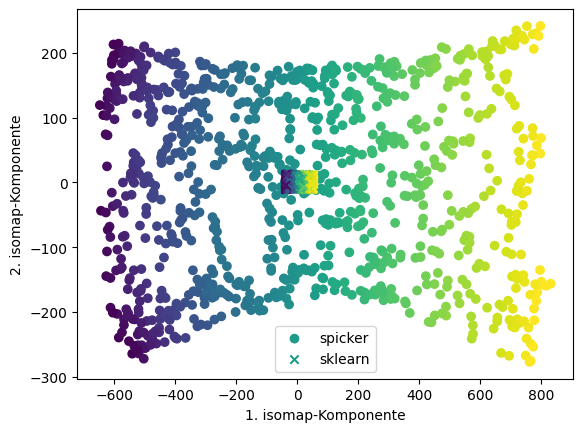

In [3]:
import numpy as np
from sklearn.datasets import make_swiss_roll
from scipy.spatial.distance import cdist
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from sklearn.manifold import Isomap

from matplotlib import pyplot as plt

# --- Zufällige Datenmatrix ---
np.random.seed(42)
X, y = make_swiss_roll(1000, random_state=100)  # X: Koordinaten, t: Variable, die die Farbe jedes Datenpunktes kodiert

# --- Visualisierung ---
ax = plt.axes(projection='3d')
ax.scatter3D(*X.T, c=y)
plt.show()

# --- zscore ---
Z = (X - X.mean(axis=0)) / X.std(axis=0)
# Alternativ: Nicht normierte Daten
Z = X

# --- Abstände aller Datenpunkte zueinander ---
M = cdist(Z, Z)

# --- Nächste Nachbarn Graphen -> NBRS ---
K = 10
NBRS = kneighbors_graph(M, K, mode="distance", include_self=True)

# --- Kürzeste Pfade -> D ---
Y = shortest_path(NBRS)
D = Y**2

# --- MDS -> C ---
N = M.shape[0]
H = np.identity(N) - 1/N * np.ones((N, N))
B = -1/2 * H @ D @ H
eig_vals, eig_vecs = np.linalg.eigh(B)
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:,idx]
idx = range(2)
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:,idx]
C = eig_vecs @ np.sqrt(np.diag(eig_vals))

# --- Vergleichswert ---
# isomap = Isomap(n_components=eig_vecs.shape[1], n_neighbors=K, metric="euclidean")
# C_ = isomap.fit_transform(Z)

# --- Visualisierung ---
# assert C.shape[1] == 2, f"{C.shape=}"
# plt.scatter(*C.T, c=y, label="spicker")
# plt.scatter(*C_.T, c=y, marker="x", label="sklearn")
# plt.legend()
# plt.xlabel("1. isomap-Komponente")
# plt.ylabel("2. isomap-Komponente")
# plt.show()